In [1]:
%load_ext autoreload
%autoreload 2
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from mne.time_frequency import tfr_morlet
from mne.time_frequency.tfr import morlet
from mne import combine_evoked
import seaborn as sns
from mne.decoding import Scaler
from sklearn.utils.class_weight import compute_sample_weight

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
paradigm = P300(tmin=-3.2, tmax=4, resample=None, fmax=None, fmin=0.1)
dataset = BNCI2014008()

In [3]:
subject, session, run = 1, "session_0", "run_0"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Not setting metadata
4200 matching events found
No baseline correction applied
0 bad epochs dropped


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,-3.199 – 4.000 sec
Baseline,off


In [4]:
scaler = Scaler(scalings='mean', with_mean=False)
epochs._data = scaler.fit_transform(epochs._data)

In [5]:
#_=epochs.plot_psd()

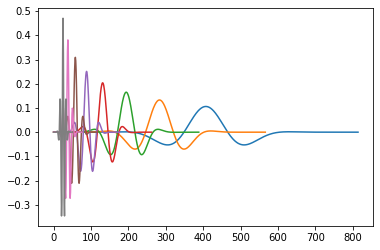

In [6]:
n_freqs=8
sfreq=32
freqs= np.geomspace(1, 16, n_freqs)
n_cycles = np.linspace(2, 4, n_freqs)
wavelets = morlet(epochs.info['sfreq'],
                  freqs, n_cycles, zero_mean=True)
for i in range(n_freqs):
    plt.plot(np.real(wavelets[i]))

In [7]:
epochs = tfr_morlet(epochs, freqs, n_cycles, return_itc=False, average=False,
                    output='complex', verbose=True, n_jobs=12, decim=int(epochs.info['sfreq']//sfreq))
#epochs.data = np.abs(epochs.data).astype(np.float64)
epochs.apply_baseline((None,None), mode='zlogratio',verbose=True)
epochs.crop(0, 1)
epochs

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   3 out of   8 | elapsed:    8.3s remaining:   13.9s
[Parallel(n_jobs=12)]: Done   5 out of   8 | elapsed:   10.9s remaining:    6.5s


Not setting metadata
Applying baseline correction (mode: zlogratio)


[Parallel(n_jobs=12)]: Done   8 out of   8 | elapsed:   11.8s finished


<EpochsTFR | time : [-0.011719, 0.988281], freq : [1.000000, 32.000000], epochs : 4200, channels : 8, ~69.7 MB>

No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied


/tmp/ipykernel_134973/4006895701.py:7: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_134973/4006895701.py:12: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_134973/4006895701.py:17: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_134973/4006895701.py:22: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


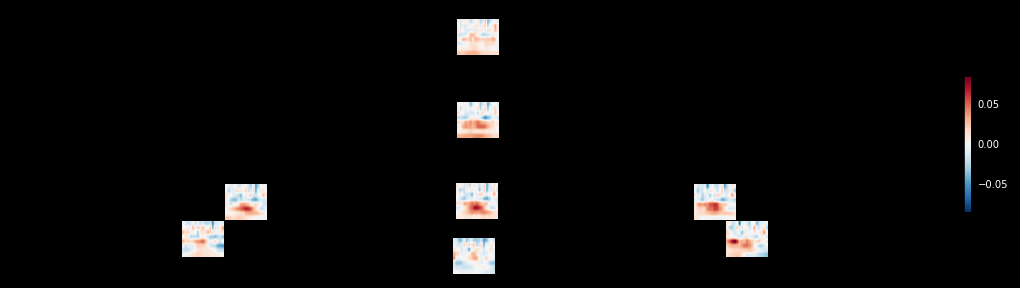

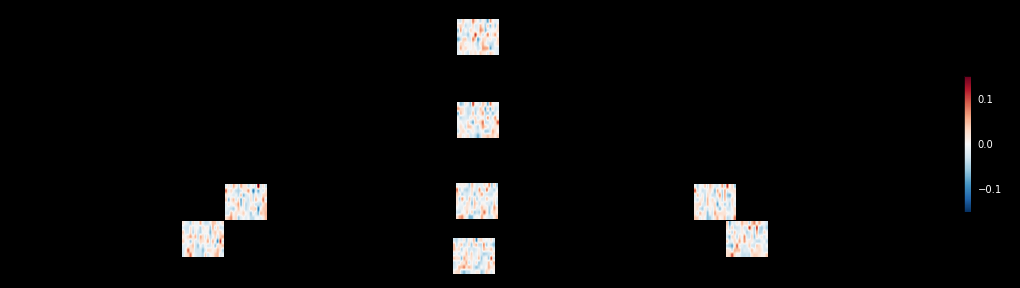

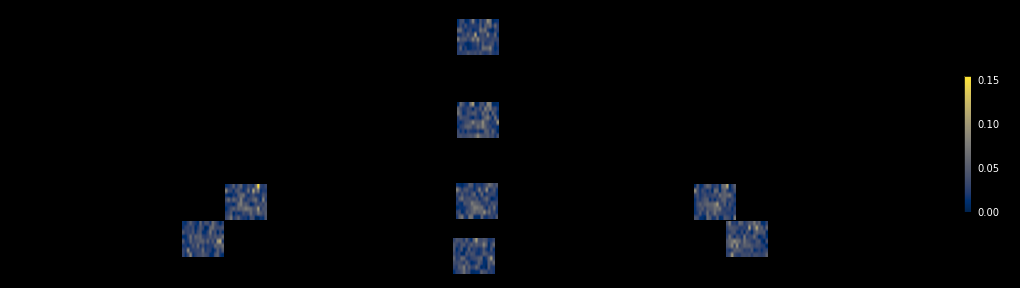

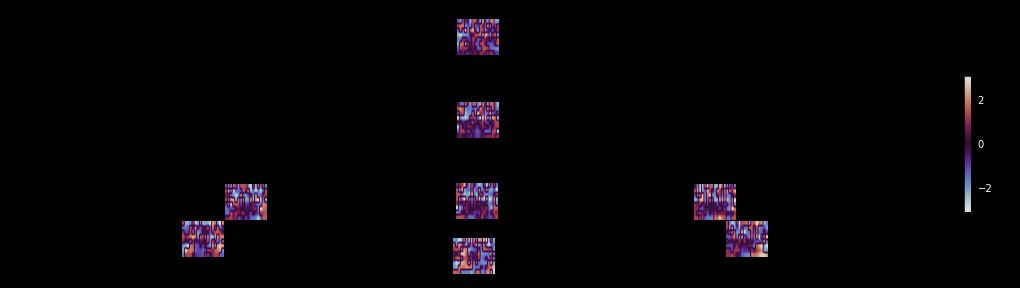

In [8]:
class_names = np.unique(labels)
contrast = epochs[class_names[1]].average() - epochs[class_names[0]].average()
contrast_r = contrast.copy()
contrast_r.data = np.real(contrast_r.data)
fig = contrast_r.plot_topo(show=False, cmap='RdBu_r')
fig.set_figwidth(16)
fig.show()
contrast_i = contrast.copy()
contrast_i.data = np.imag(contrast_i.data)
fig = contrast_i.plot_topo(show=False, cmap='RdBu_r')
fig.set_figwidth(16)
fig.show()
contrast_m = contrast.copy()
contrast_m.data = np.abs(contrast_m.data)
fig = contrast_m.plot_topo(show=False, cmap='cividis', vmin=0)
fig.set_figwidth(16)
fig.show()
contrast_p = contrast.copy()
contrast_p.data = np.angle(contrast_p.data)
fig = contrast_p.plot_topo(show=False, cmap='twilight')
fig.set_figwidth(16)
fig.show()

In [9]:
X = epochs.data
y = labels

In [32]:
hoda = HODA(max_iter=128, rank=(3,3,3), tol=0, initialize ='random', verbose=True,
            toeplitz=2, taper=None, shrinkage='oas', solver='svd')
hoda.fit(X,y),

Iteration 0  updates: [4.32346668 3.5573636  6.03133499]  objective: 0.027578813804096276
Iteration 1  updates: [2.58660879 2.12383747 2.35463902]  objective: 0.0402922211599993
Iteration 2  updates: [2.11408029 1.73418646 2.59081752]  objective: 0.045497832645857404
Iteration 3  updates: [1.8192326  1.47619935 2.02633225]  objective: 0.0461526540484732
Iteration 4  updates: [2.52379261 1.83712363 1.97273111]  objective: 0.04638401844069514
Iteration 5  updates: [2.44638043 1.45644922 1.94993406]  objective: 0.04615460748727198
Iteration 6  updates: [1.83269356 1.49276536 1.8226006 ]  objective: 0.04494889095363146
Iteration 7  updates: [1.86023811 1.51115004 1.41664503]  objective: 0.04547015734891538
Iteration 8  updates: [2.55232266 1.53039744 1.35914706]  objective: 0.044983253510140896
Iteration 9  updates: [2.40639701 1.72793734 1.43105554]  objective: 0.044705168214832
Iteration 10  updates: [2.08920753 1.81767395 1.53257053]  objective: 0.04556045001438773
Iteration 11  updates

Iteration 91  updates: [1.52566267 2.48557574 2.16266861]  objective: 0.048831581068093405
Iteration 92  updates: [1.19967709 1.78017557 2.18899512]  objective: 0.050720281903652346
Iteration 93  updates: [1.07333917 1.8884585  1.67719692]  objective: 0.050373743987858204
Iteration 94  updates: [1.12896972 1.56421615 1.67154399]  objective: 0.051687888288723734
Iteration 95  updates: [1.6149085  1.6431977  1.78013351]  objective: 0.05134994918406527
Iteration 96  updates: [1.63996453 1.18515662 1.74379946]  objective: 0.05244201412391874
Iteration 97  updates: [1.01566632 1.22248288 1.76777482]  objective: 0.052041454144594254
Iteration 98  updates: [1.06053496 0.99247105 1.70820483]  objective: 0.05305165953314819
Iteration 99  updates: [0.94627787 0.90571082 1.70373351]  objective: 0.05256213402923558
Iteration 100  updates: [0.98041016 0.81774964 1.61606798]  objective: 0.05351373202631772
Iteration 101  updates: [0.87712668 1.39630396 1.61060755]  objective: 0.052931531290515026
It

(HODA(initialize='random', max_iter=128, rank=(3, 3, 3), solver='svd',
      taper=None, toeplitz=None, tol=0, verbose=True),)

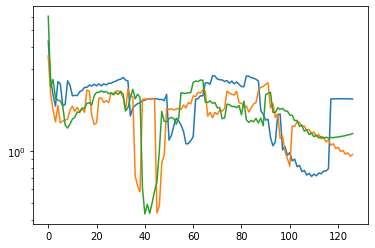

In [33]:
plt.semilogy(hoda.updates_[:,:hoda.iter_].T)
plt.show()

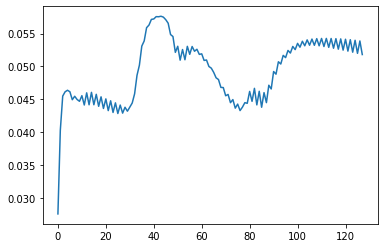

In [34]:
plt.plot(hoda.objective_)
plt.show()

In [35]:
"""
print(hoda.rank_)
for k in range(3):
    Uk = hoda.projs_[k]
    vmax = np.max(np.abs(Uk))
    fig, axs = plt.subplots(1,Uk.shape[1], figsize=(16,6))
    if Uk.shape[1]==1:
        axs = [axs]
    for i in range(Uk.shape[1]):
        if k==0:
            plot_topomap(Uk[:,i], epochs.info, axes=axs[i], show=False)        
            pass
        elif k == 2 or k==1:
            for i in range(Uk.shape[1]):
                axs[i].plot(Uk[:,i])

        else:
            sns.heatmap(Uk, cmap='RdBu_r', vmin=-vmax, vmax=vmax, ax=axs[i])
    fig.show()
"""

"\nprint(hoda.rank_)\nfor k in range(3):\n    Uk = hoda.projs_[k]\n    vmax = np.max(np.abs(Uk))\n    fig, axs = plt.subplots(1,Uk.shape[1], figsize=(16,6))\n    if Uk.shape[1]==1:\n        axs = [axs]\n    for i in range(Uk.shape[1]):\n        if k==0:\n            plot_topomap(Uk[:,i], epochs.info, axes=axs[i], show=False)        \n            pass\n        elif k == 2 or k==1:\n            for i in range(Uk.shape[1]):\n                axs[i].plot(Uk[:,i])\n\n        else:\n            sns.heatmap(Uk, cmap='RdBu_r', vmin=-vmax, vmax=vmax, ax=axs[i])\n    fig.show()\n"

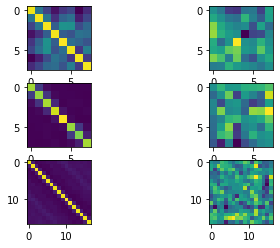

In [36]:
fig, axs = plt.subplots(3,2)
for k in range(3):
    axs[k,0].imshow(np.real(hoda.scatter_w_[k]))
    axs[k,1].imshow(np.imag(hoda.scatter_w_[k]))


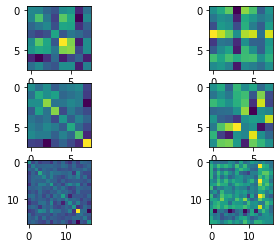

In [37]:
fig, axs = plt.subplots(3,2)
for k in range(3):
    axs[k,0].imshow(np.real(hoda.scatter_b_[k]))
    axs[k,1].imshow(np.imag(hoda.scatter_b_[k]))

In [38]:
"""
print(hoda.rank_)
for k in range(3):
    patterns = (hoda.projs_[k].T@hoda.scatter_w_[k]).T
    vmax = np.max(np.abs(patterns))
    fig, axs = plt.subplots(1,patterns.shape[1], figsize=(16,6), sharex=True, sharey=True)
    if patterns.shape[1]==1:
        axs = [axs]
    for i in range(patterns.shape[1]):
        if k==0:
            plot_topomap(patterns[:,i], epochs.info, axes=axs[i], show=False)        
            pass
        elif k == 2 or k==1:
            for i in range(patterns.shape[1]):
                axs[i].plot(patterns[:,i])
        else:
            sns.heatmap(patterns, cmap='RdBu_r', vmin=-vmax, vmax=vmax, ax=axs[i])
    fig.show()
"""

"\nprint(hoda.rank_)\nfor k in range(3):\n    patterns = (hoda.projs_[k].T@hoda.scatter_w_[k]).T\n    vmax = np.max(np.abs(patterns))\n    fig, axs = plt.subplots(1,patterns.shape[1], figsize=(16,6), sharex=True, sharey=True)\n    if patterns.shape[1]==1:\n        axs = [axs]\n    for i in range(patterns.shape[1]):\n        if k==0:\n            plot_topomap(patterns[:,i], epochs.info, axes=axs[i], show=False)        \n            pass\n        elif k == 2 or k==1:\n            for i in range(patterns.shape[1]):\n                axs[i].plot(patterns[:,i])\n        else:\n            sns.heatmap(patterns, cmap='RdBu_r', vmin=-vmax, vmax=vmax, ax=axs[i])\n    fig.show()\n"

In [39]:
Xt = hoda.transform(X)

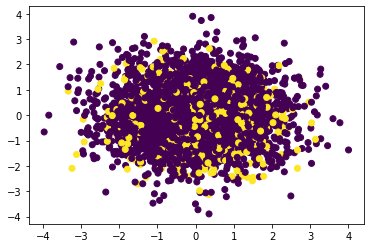

In [40]:
pca = PCA(n_components=2)
X_pc = pca.fit_transform(Xt)
plt.scatter(X_pc[:,0], X_pc[:,1],c=labels=='Target')

In [41]:
lda = LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
lda.fit(Xt,y)

LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')

In [42]:
roc_auc_score(y, lda.predict_proba(Xt)[:,1])

0.6759718367346939